In [1]:
!pip install fastcore
!pip install fastai


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from fastcore.all import *
import time
from fastai.vision.all import *
import pandas as pd
import numpy as np
import os

In [3]:
searches = 'Glaucoma', 'Cataracts', 'Uveitis', 'Crossed_Eyes', 'Bulging eyes'

# change the path
path = r'C:\Users\meare\OneDrive\Desktop\EyeCheckup\Augmented Dataset'
data_dir_list = os.listdir(path)
print(data_dir_list)

['Bulging eyes', 'Cataracts', 'Crossed_Eyes', 'Glaucoma', 'Uveitis']


In [7]:
# remove the .DS_Store from the list
# data_dir_list.remove('.DS_Store')
# print(data_dir_list)
if '.DS_Store' in data_dir_list:
    data_dir_list.remove('.DS_Store')

In [8]:
get_items = get_image_files(path)

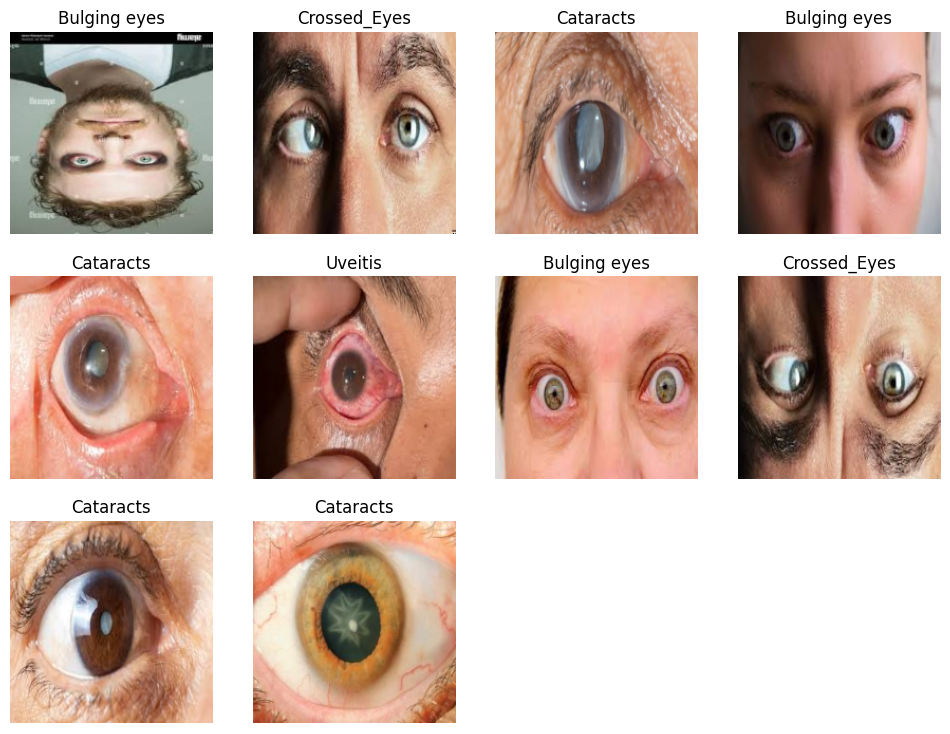

In [9]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path)

dls.show_batch(max_n=10)

In [10]:
dls.vocab

['Bulging eyes', 'Cataracts', 'Crossed_Eyes', 'Glaucoma', 'Uveitis']

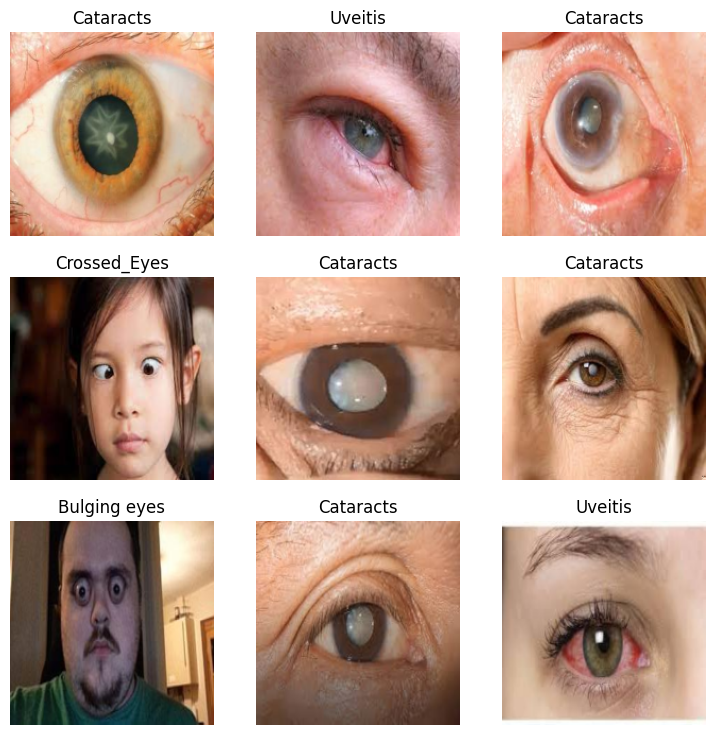

In [11]:
blocks = (ImageBlock, CategoryBlock),
get_items = get_image_files,
splitter = RandomSplitter(valid_pct=0.2, seed=42),
dls.show_batch()

In [12]:
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(50)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\meare/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:13<00:00, 6.35MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,2.105687,1.214542,0.557823,01:19


epoch,train_loss,valid_loss,accuracy,time
0,0.778404,0.834295,0.714286,01:24
1,0.546710,0.617037,0.775510,01:24
2,0.422324,0.524946,0.802721,01:23
3,0.322026,0.443883,0.829932,01:22
4,0.250209,0.381898,0.843537,01:24
5,0.199002,0.354532,0.870748,01:21
6,0.159347,0.355644,0.884354,01:24
7,0.132889,0.363370,0.877551,01:21
8,0.109561,0.399006,0.863946,01:21
9,0.095136,0.417340,0.850340,01:21


In [13]:
learn.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 192 x 192)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 96 x 96   
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 48 x 48   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

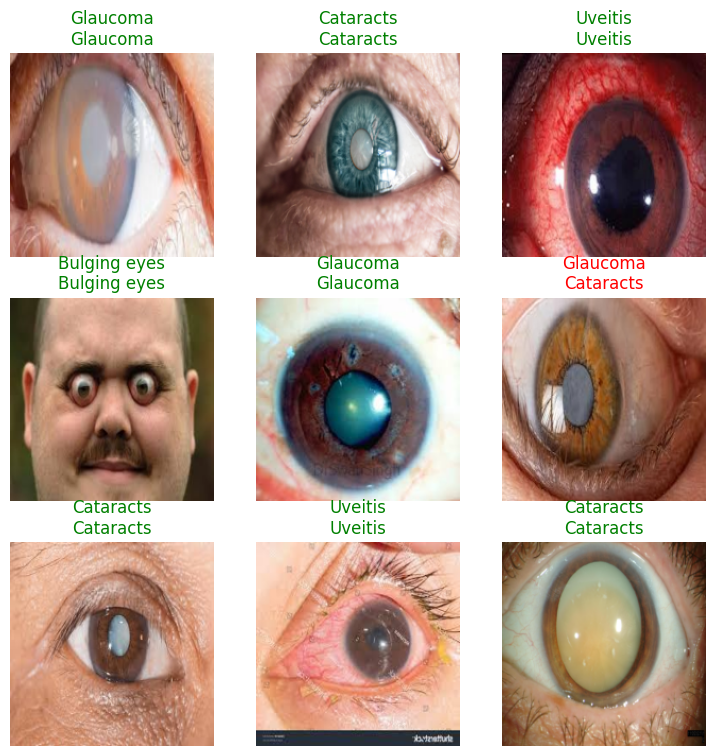

In [14]:
learn.show_results()

<div></div>

SuggestedLRs(valley=9.120108734350652e-05)

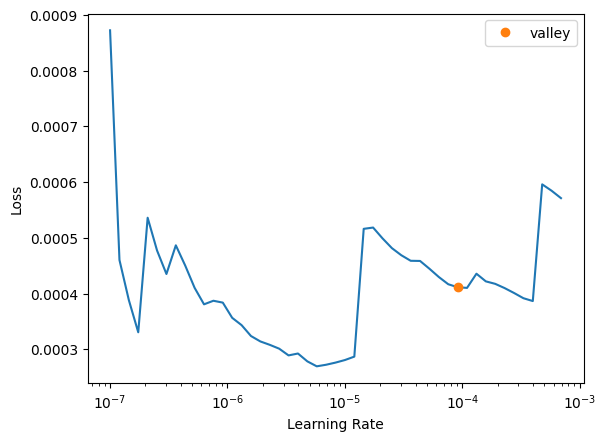

In [15]:
learn.lr_find()

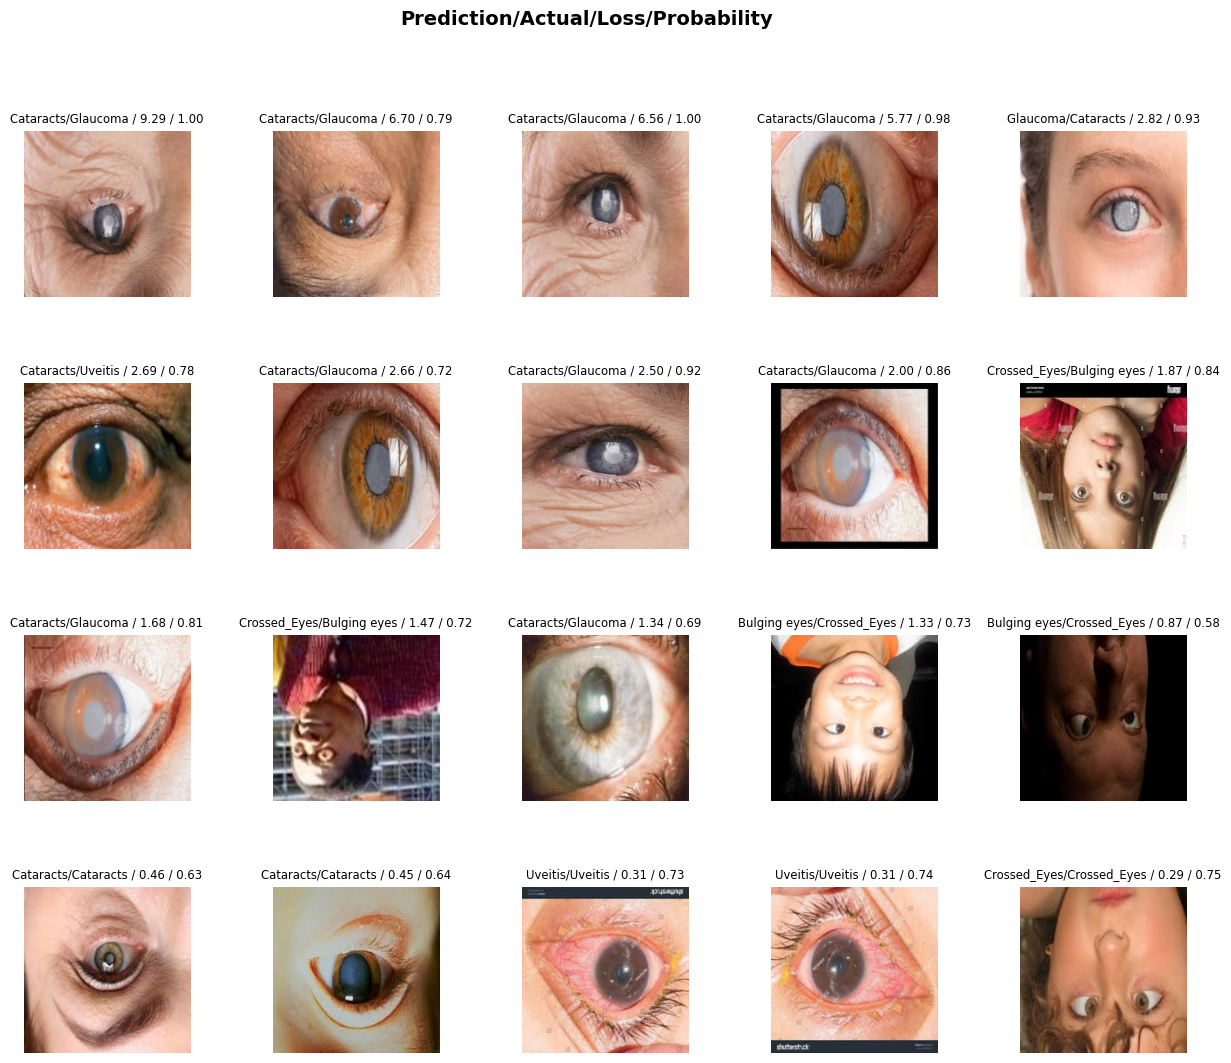

In [16]:
import matplotlib.pyplot as plt

# Set font size for the entire plot
plt.rcParams['font.size'] = 7

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(20)
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

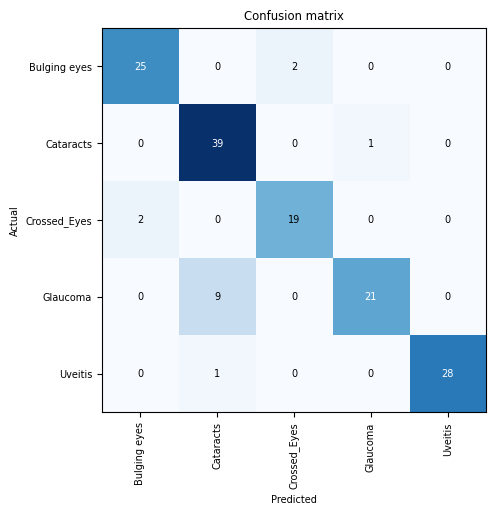

In [17]:
interp.plot_confusion_matrix(figsize=(5, 5))

In [18]:
# Save the trained model
learn.export('eye_disease_model.pkl')